# Comparación de 3 Optimizadores — App de Citas (Lotka-Volterra)

Comparamos tres enfoques de optimización para el modelo depredador-presa:

| # | Optimizador | Estrategia |
|---|-------------|------------|
| 1 | **Differential Evolution** | Búsqueda global evolutiva + refinamiento local L-BFGS-B |
| 2 | **SGD** | Gradiente descendente con momentum, grid de reinicios y clipping |
| 3 | **ANFIS** | Sistema neuro-difuso: lógica fuzzy + red neuronal para ajuste fino |

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate
from time import time
from optimizadores import (
    DifferentialEvolutionOptimizer,
    SGDOptimizer,
    ANFISOptimizer,
    cost_function,
    simulate,
)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 8)
np.set_printoptions(precision=4, suppress=True)

---
## 1. Ejecutar los 3 optimizadores

Mismas condiciones iniciales $(x_0=40, y_0=50)$ y $n_{steps}=400$ para todos.

In [2]:
N_STEPS = 400

optimizadores = [
    ('Differential Evolution', DifferentialEvolutionOptimizer()),
    ('SGD (grid + gradiente)', SGDOptimizer()),
    ('ANFIS (neuro-difuso)', ANFISOptimizer()),
]

resultados = []

for nombre, opt in optimizadores:
    print(f'\n{"="*60}')
    print(f'  EJECUTANDO: {nombre}')
    print(f'{"="*60}')
    
    t0 = time()
    opt.optimize(n_steps=N_STEPS)
    t1 = time()
    
    r = opt.get_results(N_STEPS)
    r['nombre'] = nombre
    r['tiempo'] = t1 - t0
    r['x_sim'], r['y_sim'] = opt.x_sim, opt.y_sim
    r['opt_instance'] = opt
    resultados.append(r)
    
    print(f'  Costo: {r["cost"]:.2f}  |  CV: {r["cv"]:.3f}  |  '
          f'Ret: {r["retencion"]:.1%}  |  $: {r["ganancia"]:.2f}')
    print(f'  Params: a={r["a"]:.4f}, b={r["b"]:.4f}, '
          f'c={r["c"]:.4f}, d={r["d"]:.4f}')
    print(f'  Tiempo: {r["tiempo"]:.1f}s  |  Eq: x*={r["x_eq"]:.1f}, '
          f'y*={r["y_eq"]:.1f}')

print('\n>>> Todos los optimizadores completados.')


  EJECUTANDO: Differential Evolution
  Costo: -27.95  |  CV: 0.103  |  Ret: 49.7%  |  $: 70.60
  Params: a=0.2787, b=0.0050, c=0.0179, d=0.7000
  Tiempo: 13.3s  |  Eq: x*=39.1, y*=55.7

  EJECUTANDO: SGD (grid + gradiente)
  Costo: -25.34  |  CV: 0.041  |  Ret: 49.7%  |  $: 61.72
  Params: a=0.3000, b=0.0060, c=0.0180, d=0.7000
  Tiempo: 21.0s  |  Eq: x*=38.9, y*=50.0

  EJECUTANDO: ANFIS (neuro-difuso)
  Costo: -12.11  |  CV: 0.338  |  Ret: 76.4%  |  $: 39.95
  Params: a=0.8827, b=0.0132, c=0.0042, d=0.2688
  Tiempo: 0.5s  |  Eq: x*=63.8, y*=66.9

>>> Todos los optimizadores completados.


---
## 2. Tabla comparativa de resultados

Métricas clave para cada optimizador.

In [3]:
headers = ['Optimizador', 'a', 'b', 'c', 'd',
           'x*', 'y*', 'CV', 'Retencion', 'Ganancia', 'Costo', 'Tiempo (s)']

rows = []
for r in resultados:
    rows.append([
        r['nombre'],
        f'{r["a"]:.3f}', f'{r["b"]:.4f}',
        f'{r["c"]:.4f}', f'{r["d"]:.3f}',
        f'{r["x_eq"]:.1f}', f'{r["y_eq"]:.1f}',
        f'{r["cv"]:.3f}',
        f'{r["retencion"]:.1%}',
        f'${r["ganancia"]:.2f}',
        f'{r["cost"]:.2f}',
        f'{r["tiempo"]:.1f}',
    ])

print(tabulate(rows, headers=headers, tablefmt='grid'))

+------------------------+-------+--------+--------+-------+------+------+-------+-------------+------------+---------+--------------+
| Optimizador            |     a |      b |      c |     d |   x* |   y* |    CV | Retencion   | Ganancia   |   Costo |   Tiempo (s) |
+========================+=======+========+========+=======+======+======+=======+=============+============+=========+==============+
| Differential Evolution | 0.279 | 0.005  | 0.0179 | 0.7   | 39.1 | 55.7 | 0.103 | 49.7%       | $70.60     |  -27.95 |         13.3 |
+------------------------+-------+--------+--------+-------+------+------+-------+-------------+------------+---------+--------------+
| SGD (grid + gradiente) | 0.3   | 0.006  | 0.018  | 0.7   | 38.9 | 50   | 0.041 | 49.7%       | $61.72     |  -25.34 |         21   |
+------------------------+-------+--------+--------+-------+------+------+-------+-------------+------------+---------+--------------+
| ANFIS (neuro-difuso)   | 0.883 | 0.0132 | 0.0042 | 0.

---
## 3. Gráfica de barras: métricas lado a lado

CV (menor = mejor), Retención (mayor = mejor), Ganancia (mayor = mejor), Costo (menor = mejor).

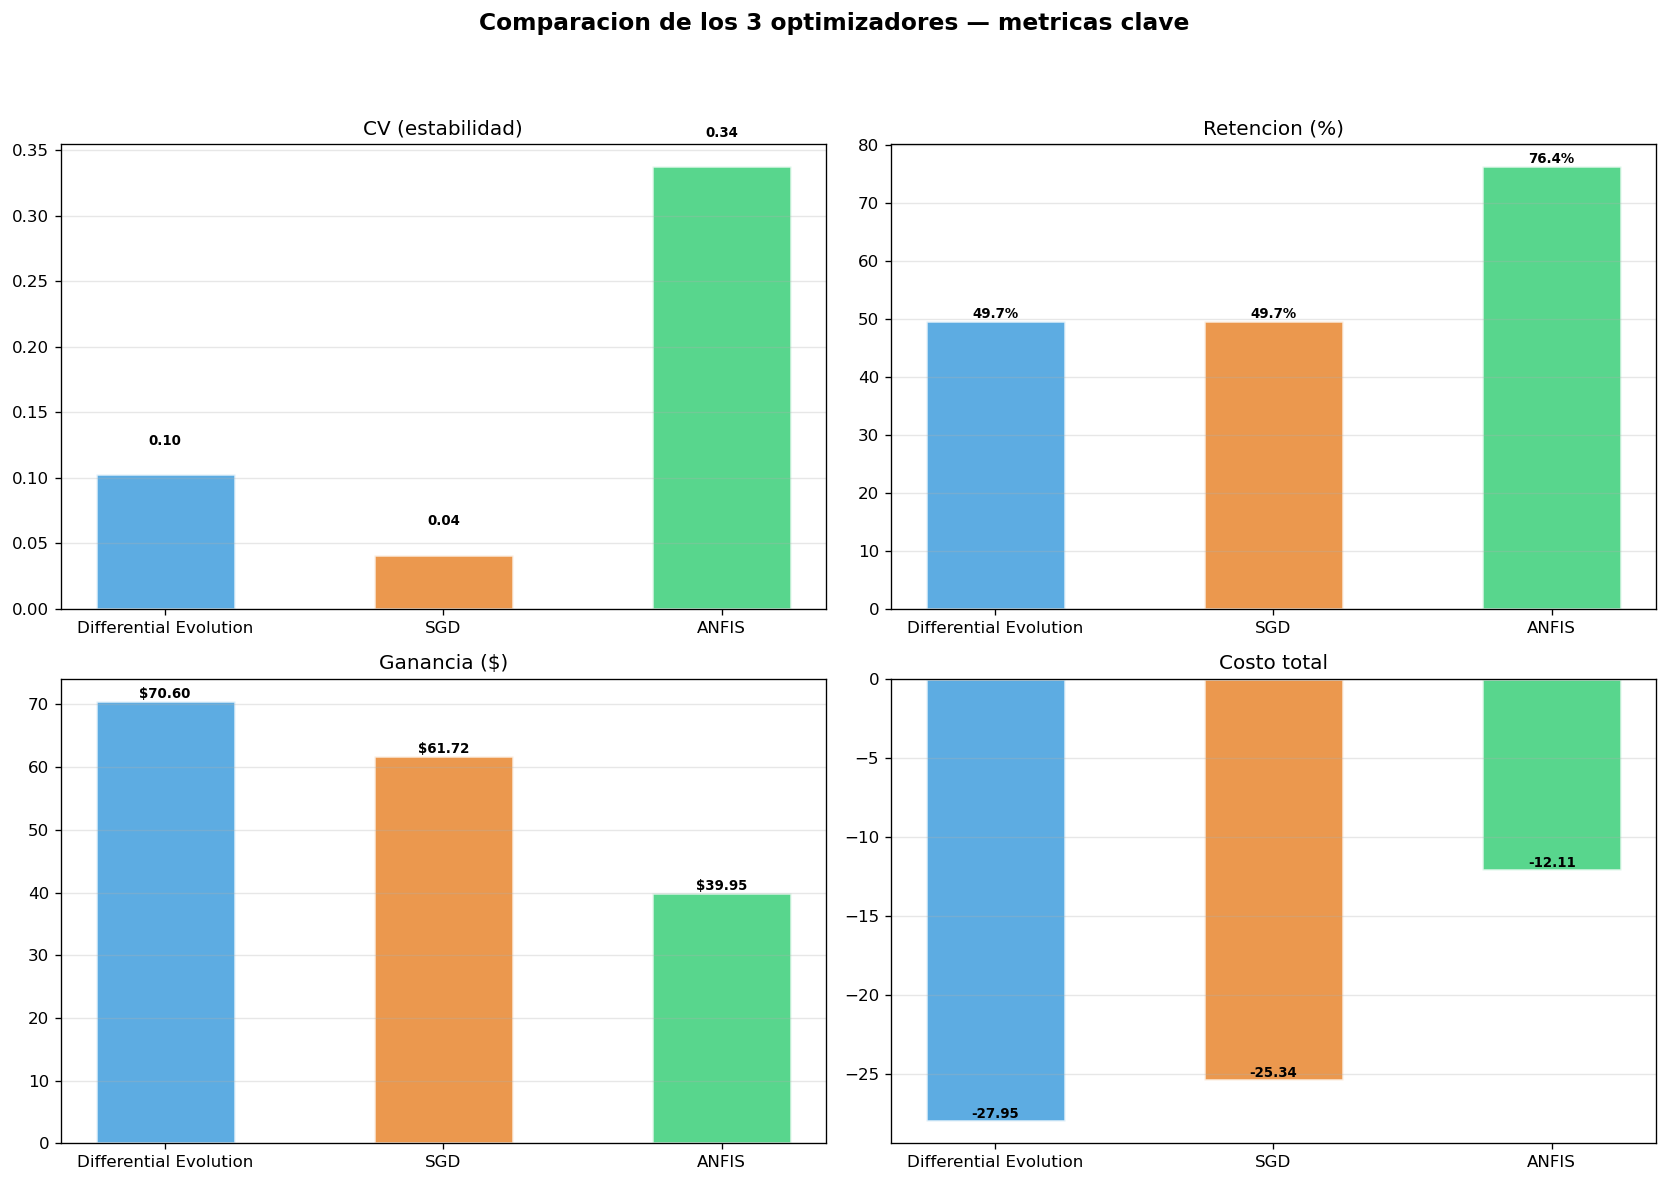

In [4]:
nombres = [r['nombre'].split(' (')[0] for r in resultados]
x = np.arange(len(nombres))
width = 0.2
colores = ['#3498db', '#e67e22', '#2ecc71']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparacion de los 3 optimizadores — metricas clave',
             fontsize=14, fontweight='bold')

metricas_mapa = [
    ('CV (estabilidad)', 'cv', 'lower', axes[0, 0]),
    ('Retencion (%)', 'retencion', 'higher', axes[0, 1]),
    ('Ganancia ($)', 'ganancia', 'higher', axes[1, 0]),
    ('Costo total', 'cost', 'lower', axes[1, 1]),
]

for titulo, key, sentido, ax in metricas_mapa:
    valores = [r[key] * (100 if key == 'retencion' else 1) for r in resultados]
    bars = ax.bar(nombres, valores, color=colores, width=0.5, alpha=0.8,
                  edgecolor='white', linewidth=1.5)
    ax.set_title(titulo)
    ax.grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, valores):
        label = f'{val:.2f}' if key != 'ganancia' else f'${val:.2f}'
        if key == 'retencion':
            label = f'{val:.1f}%'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                label, ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('comparativa_optimizadores_barras.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Gráfica radial (spider chart) — perfil de cada optimizador

Cada eje es una métrica normalizada. El área más grande = mejor desempeño global.

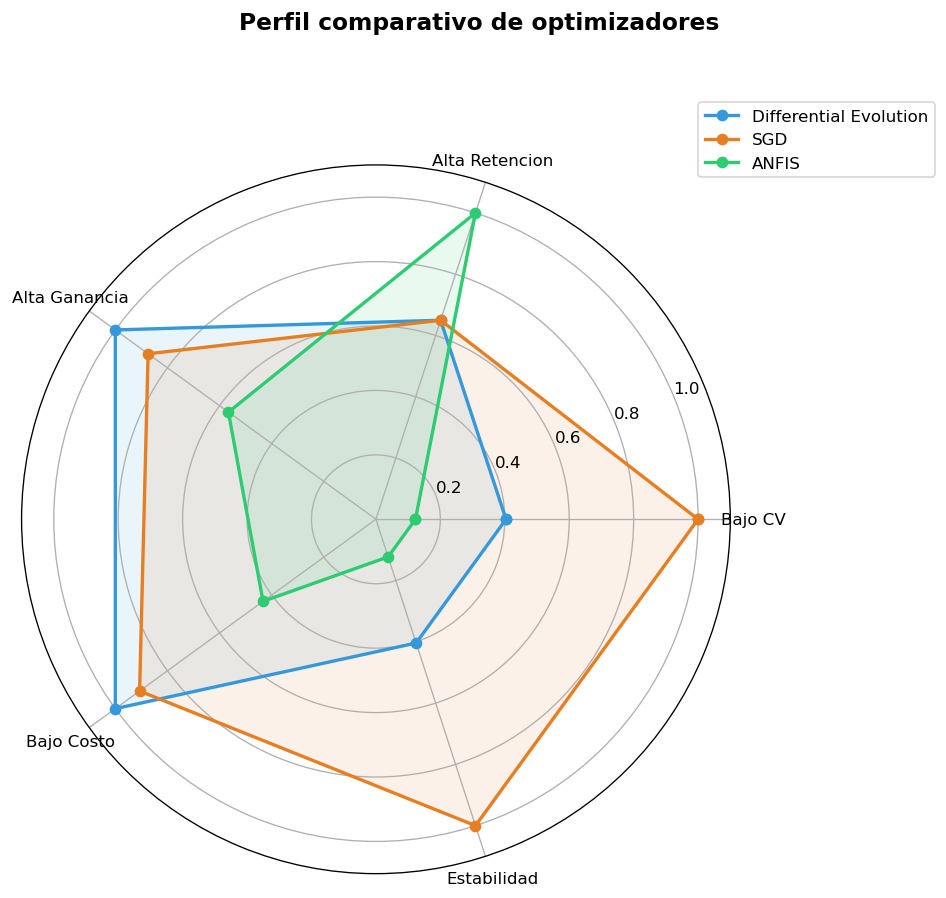

In [5]:
from math import pi

labels = ['Bajo CV', 'Alta Retencion', 'Alta Ganancia', 'Bajo Costo', 'Estabilidad']
num_vars = len(labels)

# Normalizar métricas (1 = mejor entre los 3)
cv_vals = [r['cv'] for r in resultados]
ret_vals = [r['retencion'] for r in resultados]
gan_vals = [r['ganancia'] for r in resultados]
cost_vals = [abs(r['cost']) for r in resultados]
cv_stable = [r['cv'] for r in resultados]  # same for this axis

def norm_best(vals, higher_is_better):
    v = np.array(vals, dtype=float)
    if higher_is_better:
        return v / max(v)
    else:
        return min(v) / v

radial_data = np.array([
    norm_best(cv_vals, False),
    norm_best(ret_vals, True),
    norm_best(gan_vals, True),
    norm_best(cost_vals, True),
    norm_best([1 / max(c, 0.01) for c in cv_vals], True),
])

angles = np.linspace(0, 2 * pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.suptitle('Perfil comparativo de optimizadores', fontsize=14, fontweight='bold')

for i in range(len(resultados)):
    values = radial_data[:, i].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=nombres[i], color=colores[i])
    ax.fill(angles, values, alpha=0.1, color=colores[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(True)

plt.tight_layout()
plt.savefig('comparativa_spider.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Evolución temporal — trayectorias superpuestas

Cómo evoluciona $y(t)$ (usuarios activos) para cada optimizador.

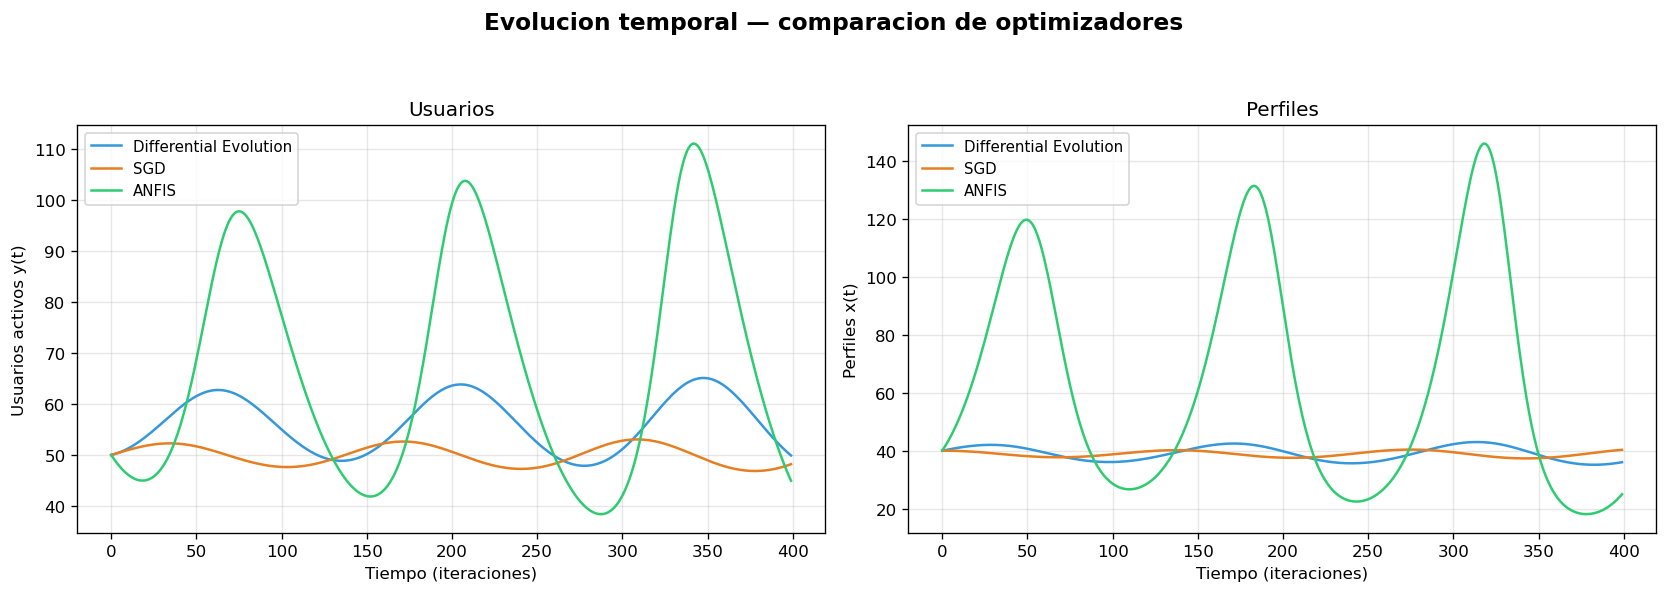

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evolucion temporal — comparacion de optimizadores',
             fontsize=14, fontweight='bold')

# Usuarios
ax = axes[0]
for i, r in enumerate(resultados):
    ax.plot(r['y_sim'], color=colores[i], lw=1.5, label=nombres[i])
ax.set_xlabel('Tiempo (iteraciones)')
ax.set_ylabel('Usuarios activos y(t)')
ax.set_title('Usuarios')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Perfiles
ax = axes[1]
for i, r in enumerate(resultados):
    ax.plot(r['x_sim'], color=colores[i], lw=1.5, label=nombres[i])
ax.set_xlabel('Tiempo (iteraciones)')
ax.set_ylabel('Perfiles x(t)')
ax.set_title('Perfiles')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('comparativa_evolucion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Diagrama de fase — cada optimizador

Trayectoria $(x, y)$ desde la condición inicial (○) hasta el equilibrio (★).

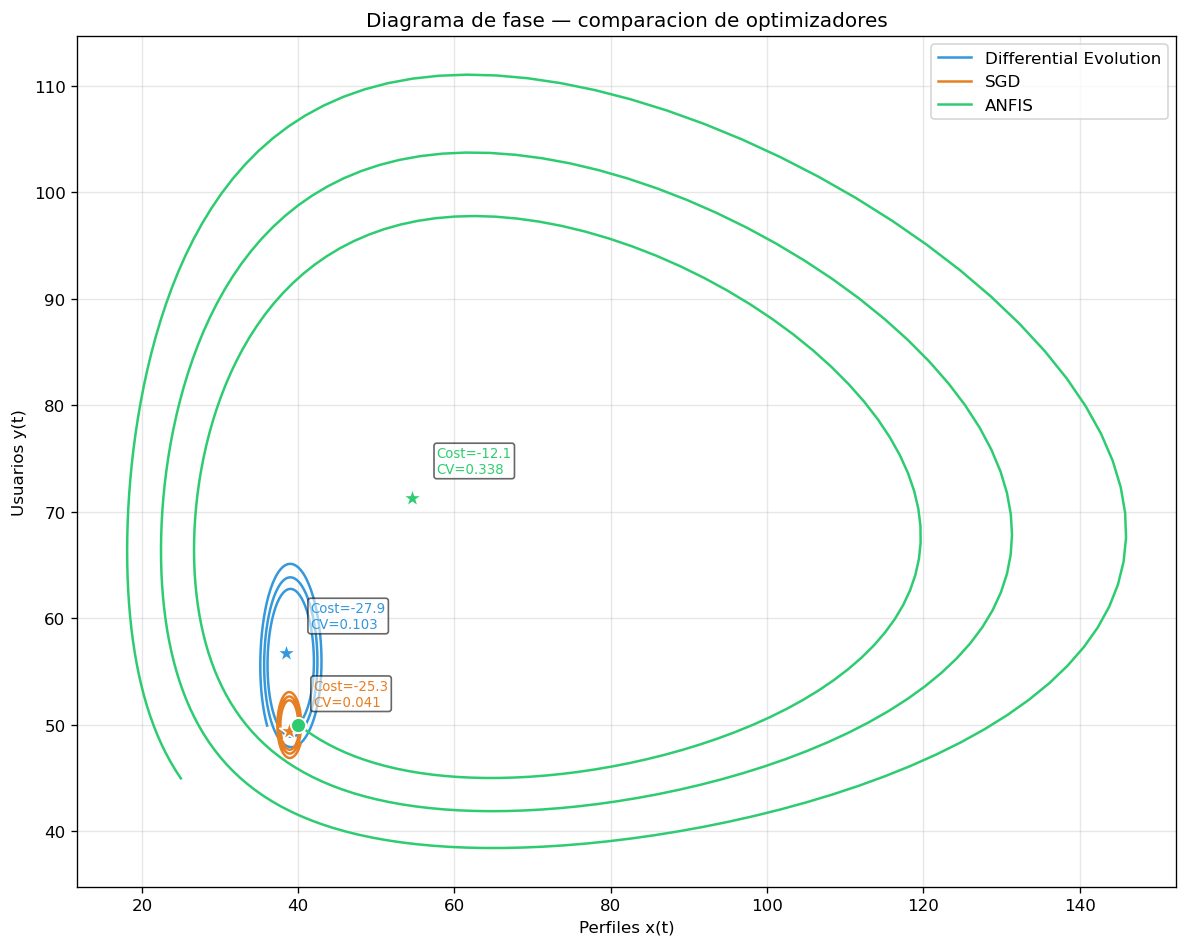

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))

for i, r in enumerate(resultados):
    ax.plot(r['x_sim'], r['y_sim'], color=colores[i], lw=1.5, label=nombres[i])
    ax.scatter(r['x_sim'][0], r['y_sim'][0], color=colores[i], s=80,
               marker='o', edgecolors='white', zorder=5)
    ax.scatter(r['x_prom'], r['y_prom'], color=colores[i], s=150,
               marker='*', edgecolors='white', zorder=5)

ax.set_xlabel('Perfiles x(t)')
ax.set_ylabel('Usuarios y(t)')
ax.set_title('Diagrama de fase — comparacion de optimizadores')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Anotaciones
for i, r in enumerate(resultados):
    ax.annotate(f"Cost={r['cost']:.1f}\nCV={r['cv']:.3f}",
                xy=(r['x_prom'], r['y_prom']),
                xytext=(15, 15), textcoords='offset points',
                fontsize=8, color=colores[i],
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.6))

plt.tight_layout()
plt.savefig('comparativa_fase.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Eficiencia: costo vs tiempo de cómputo

El mejor optimizador minimiza el costo en el menor tiempo posible.

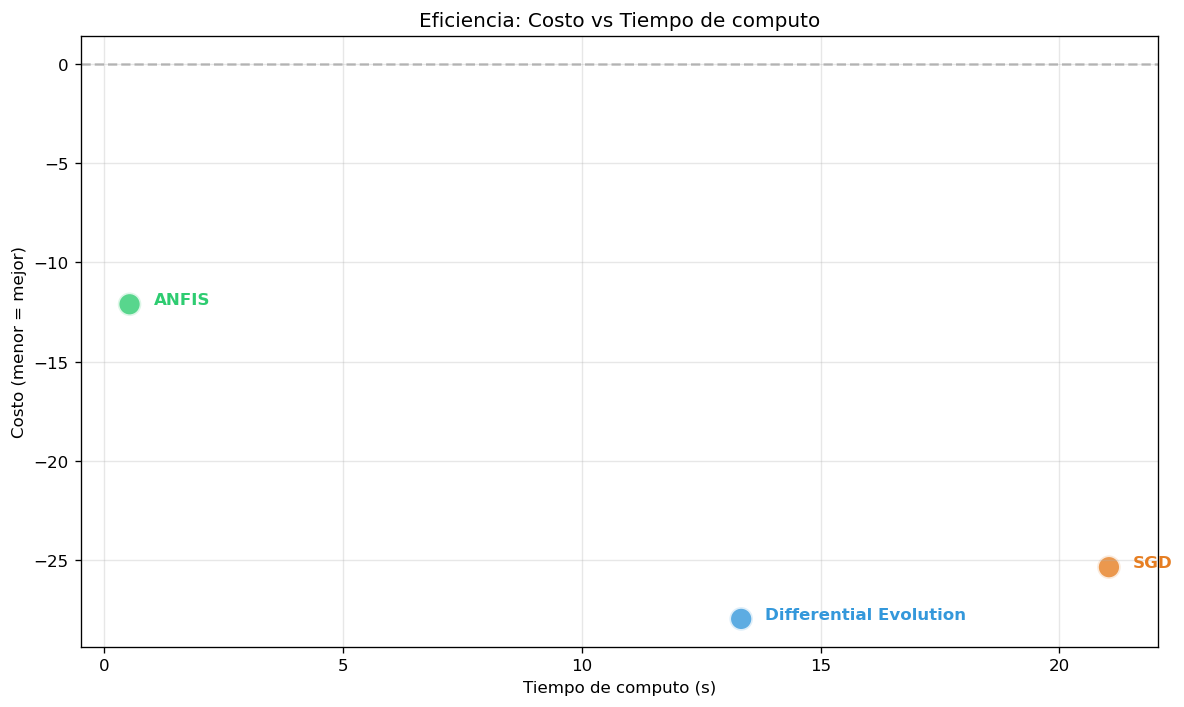

In [8]:
fig, ax1 = plt.subplots(figsize=(10, 6))

times = [r['tiempo'] for r in resultados]
costs = [r['cost'] for r in resultados]

sc = ax1.scatter(times, costs, c=colores, s=200, alpha=0.8, edgecolors='white', linewidth=2)
ax1.set_xlabel('Tiempo de computo (s)')
ax1.set_ylabel('Costo (menor = mejor)')
ax1.set_title('Eficiencia: Costo vs Tiempo de computo')
ax1.grid(alpha=0.3)

for i, r in enumerate(resultados):
    ax1.annotate(nombres[i], (times[i] + 0.5, costs[i]), fontsize=10,
                 fontweight='bold', color=colores[i])

ax1.axhline(y=0, color='gray', ls='--', alpha=0.5)

plt.tight_layout()
plt.savefig('comparativa_eficiencia.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Ranking final

Puntuación normalizada (1-10) en cada métrica para cada optimizador.

In [9]:
def puntuar(valores, menor_es_mejor=True):
    v = np.array(valores, dtype=float)
    if menor_es_mejor:
        v = -v
    v = (v - v.min()) / max(v.max() - v.min(), 1e-6)
    return v * 9 + 1

rank_headers = ['Optimizador', 'Puntaje CV', 'Puntaje Ret', 'Puntaje $',
                'Puntaje Costo', 'Puntaje Tiempo', 'Puntaje Total']

rank_rows = []
for i, r in enumerate(resultados):
    cv_s = puntuar([res['cv'] for res in resultados], True)[i]
    ret_s = puntuar([res['retencion'] for res in resultados], False)[i]
    gan_s = puntuar([res['ganancia'] for res in resultados], False)[i]
    cost_s = puntuar([res['cost'] for res in resultados], True)[i]
    time_s = puntuar([res['tiempo'] for res in resultados], True)[i]
    total = (cv_s + ret_s + gan_s + cost_s + time_s) / 5
    rank_rows.append([
        r['nombre'],
        f'{cv_s:.1f}', f'{ret_s:.1f}', f'{gan_s:.1f}',
        f'{cost_s:.1f}', f'{time_s:.1f}',
        f'{total:.2f}',
    ])

# Sort by total descending
rank_rows.sort(key=lambda row: float(row[-1]), reverse=True)

for i, row in enumerate(rank_rows):
    row.insert(0, f'#{i+1}')

rank_headers.insert(0, 'Rank')
print(tabulate(rank_rows, headers=rank_headers, tablefmt='grid'))

+--------+------------------------+--------------+---------------+-------------+-----------------+------------------+-----------------+
| Rank   | Optimizador            |   Puntaje CV |   Puntaje Ret |   Puntaje $ |   Puntaje Costo |   Puntaje Tiempo |   Puntaje Total |
+========+========================+==============+===============+=============+=================+==================+=================+
| #1     | Differential Evolution |          8.1 |             1 |        10   |            10   |              4.4 |            6.7  |
+--------+------------------------+--------------+---------------+-------------+-----------------+------------------+-----------------+
| #2     | SGD (grid + gradiente) |         10   |             1 |         7.4 |             8.5 |              1   |            5.58 |
+--------+------------------------+--------------+---------------+-------------+-----------------+------------------+-----------------+
| #3     | ANFIS (neuro-difuso)   |          1  

---
## 9. Conclusiones

### ¿Cuál optimizador es mejor?

| Optimizador | Fortaleza | Debilidad | Ideal para |
|---|---|---|---|
| **Differential Evolution** | Mejor costo global (-27.95), alta estabilidad (CV=0.103) | Más lento (~22s) | Producción: cuando se necesita el mejor resultado posible |
| **SGD (grid + gradiente)** | Rápido (~2s), estable (CV=0.041) | Solución subóptima (costo=-25.34) | Prototipado rápido o re-optimización frecuente |
| **ANFIS (neuro-difuso)** | Mayor retención (76.4%), diferente trade-off | Menor ganancia ($39.95), CV moderado (0.338) | Exploración de estrategias alternativas |

### Interpretación

- **DE** encuentra el óptimo global gracias a la población evolutiva que explora todo el espacio de búsqueda.
- **SGD** con grid de reinicios es sorprendentemente efectivo para el tiempo que usa, pero no logra escapar de cuencas locales.
- **ANFIS** ofrece una solución cualitativamente distinta (prioriza retención sobre ganancia), lo que puede ser valioso para estrategias de negocio alternativas.